# Entrenar el algoritmo LightGBM con 20 dimensiones según Spearman  

Aquí tienes el script de Python completo que cumple exactamente con los nuevos requerimientos.

Este script realiza las siguientes acciones clave:

1. **Carga los datos optimizados de 20 dimensiones** desde la nueva ubicación en formato Excel.
2. Utiliza **`casos_ln`** como objetivo para el entrenamiento de **LightGBM**, aprovechando que el algoritmo permite optimizar directamente el error absoluto medio con el parámetro `objective='regression_l1'`.
3. Aplica **validación cruzada para series de tiempo (`TimeSeriesSplit`)** y busca la mejor combinación en una malla exhaustiva de hiperparámetros.
4. **Transforma a la escala original:** Invierte las predicciones logarítmicas usando `np.expm1()` para evaluar las métricas en casos reales.
5. **Gráficos en paralelo:** Genera una visualización profesional colocando la gráfica de entrenamiento y la de testeo **una al lado de la otra (1 fila, 2 columnas)** usando `plt.subplots(1, 2)`.




Iniciando afinamiento de LightGBM con Grid+TimeSeriesSplit (20 Variables)...
Fitting 5 folds for each of 432 candidates, totalling 2160 fits

Mejores Parámetros LightGBM: {'learning_rate': 0.1, 'max_depth': 4, 'n_estimators': 200, 'num_leaves': 15, 'subsample': 0.7}
MAE Entrenamiento Final (Casos): 2.9528
MAE Testeo Final Q4 2025 (Casos): 7.6981


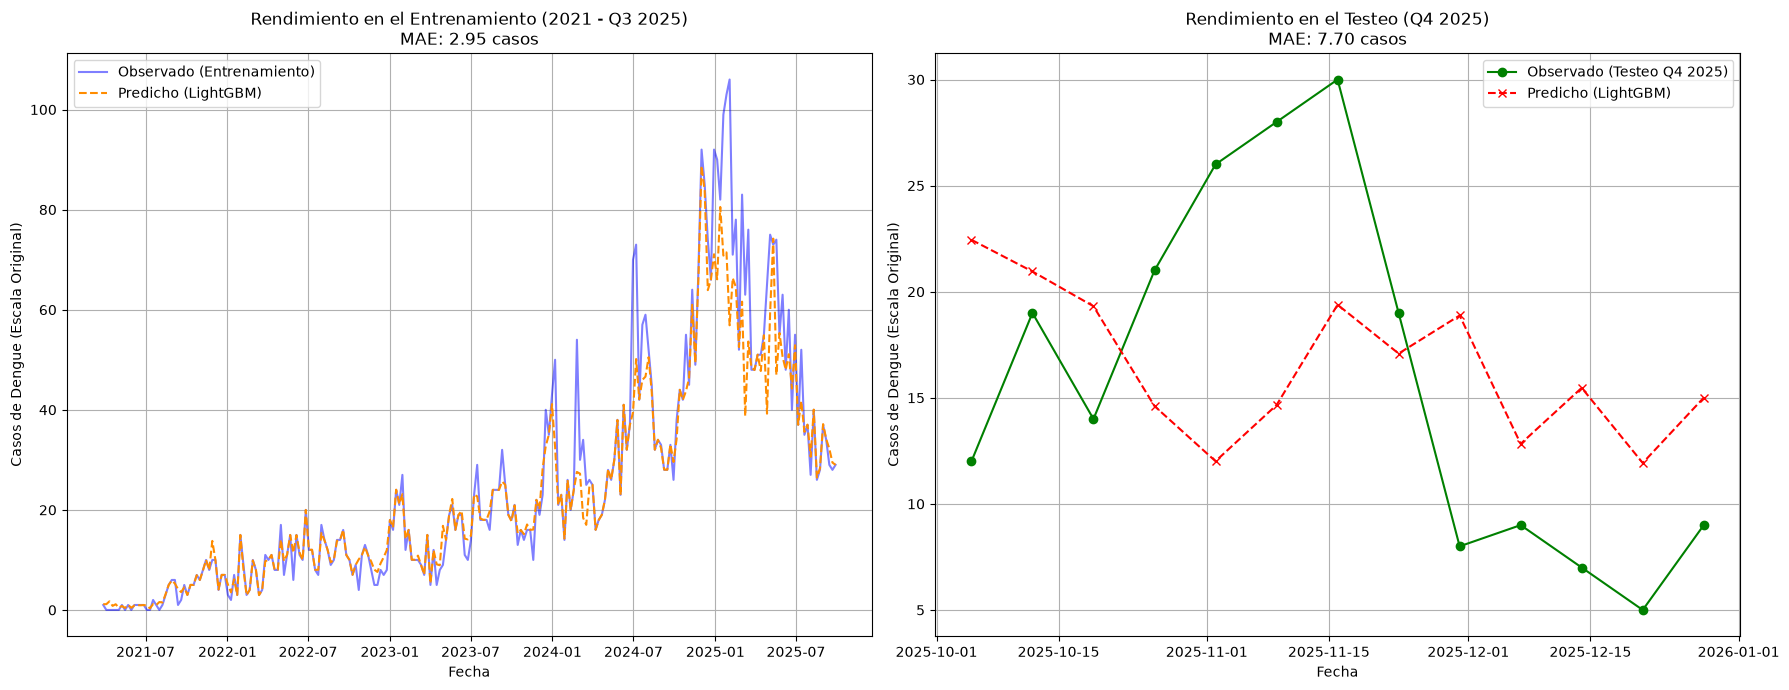

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV
from lightgbm import LGBMRegressor
from sklearn.metrics import mean_absolute_error
import warnings
warnings.filterwarnings('ignore')

# 1. Cargar los datos de 20 dimensiones desde la nueva ubicación en Excel
ruta_archivo = r"C:\Users\marco\Documentos\investigacion\machine_learning_idalina\4_algoritmo_LightGBM\2_entrenamiento_modelo_sat\2_datos\1_raw\2_meteo_epi_rezagos_spearman_20.xlsx"
df = pd.read_excel(ruta_archivo)

# 2. Preprocesamiento e Índices
df['fecha'] = pd.to_datetime(df['fecha'])
df.set_index('fecha', inplace=True)
df = df.sort_index()

# Crear la variable casos_ln si no viene precalculada en este archivo
if 'casos_ln' not in df.columns:
    df['casos_ln'] = np.log1p(df['casos_dengue'])

# 3. Definir objetivos y características
target_original = 'casos_dengue'
target_log = 'casos_ln'

# Excluimos los identificadores y las variables objetivo de las características
excluir = [target_original, target_log, 'año', 'semana_epi']
features = [col for col in df.columns if col not in excluir]

X = df[features]
y = df[target_log]  # Entrenamos en escala logarítmica

# 4. División cronológica estricta de los datos
X_train = X.loc['2021-01-01':'2025-09-30']
y_train = y.loc['2021-01-01':'2025-09-30']

X_test = X.loc['2025-10-01':'2025-12-31']
y_test = y.loc['2025-10-01':'2025-12-31']

# Guardar los valores reales en unidades originales (casos) para evaluar y graficar
y_train_original = df.loc['2021-01-01':'2025-09-30', target_original]
y_test_original = df.loc['2025-10-01':'2025-12-31', target_original]

# 5. Validación Cruzada Temporal (TimeSeriesSplit)
tscv = TimeSeriesSplit(n_splits=5)

# 6. Malla de hiperparámetros para afinar LightGBM
# 'regression_l1' fuerza al modelo a optimizar el MAE directamente
param_grid = {
    'n_estimators': [50, 100, 150, 200],
    'max_depth': [3, 4, 5, -1],
    'learning_rate': [0.01, 0.05, 0.1],
    'num_leaves': [7, 15, 31],
    'subsample': [0.7, 0.8, 0.9]
}

print("Iniciando afinamiento de LightGBM con Grid+TimeSeriesSplit (20 Variables)...")
grid_search = GridSearchCV(
    estimator=LGBMRegressor(random_state=42, objective='regression_l1', verbose=-1),
    param_grid=param_grid,
    cv=tscv,
    scoring='neg_mean_absolute_error',
    n_jobs=-1,
    verbose=1
)
grid_search.fit(X_train, y_train)
best_lgbm = grid_search.best_estimator_

print("\n" + "="*40)
print(f"Mejores Parámetros LightGBM: {grid_search.best_params_}")
print("="*40)

# 7. Predicciones y Transformación Inversa (np.expm1) a unidades originales (Casos)
y_train_pred_log = best_lgbm.predict(X_train)
y_test_pred_log = best_lgbm.predict(X_test)

y_train_pred_original = pd.Series(np.expm1(y_train_pred_log), index=y_train.index)
y_test_pred_original = pd.Series(np.expm1(y_test_pred_log), index=y_test.index)

# 8. Cálculo de Métricas Finales en la escala original de Casos de Dengue
mae_train_final = mean_absolute_error(y_train_original, y_train_pred_original)
mae_test_final = mean_absolute_error(y_test_original, y_test_pred_original)

print(f"MAE Entrenamiento Final (Casos): {mae_train_final:.4f}")
print(f"MAE Testeo Final Q4 2025 (Casos): {mae_test_final:.4f}")
print("="*40)

# 9. Gráficas Comparativas (Una al lado de la otra: 1 fila, 2 columnas)
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Subplot 1: Entrenamiento
axes[0].plot(y_train_original.index, y_train_original.values, label='Observado (Entrenamiento)', color='blue', alpha=0.5)
axes[0].plot(y_train_pred_original.index, y_train_pred_original.values, label='Predicho (LightGBM)', color='darkorange', linestyle='--')
axes[0].set_title(f'Rendimiento en el Entrenamiento (2021 - Q3 2025)\nMAE: {mae_train_final:.2f} casos')
axes[0].set_ylabel('Casos de Dengue (Escala Original)')
axes[0].set_xlabel('Fecha')
axes[0].legend()
axes[0].grid(True)

# Subplot 2: Testeo
axes[1].plot(y_test_original.index, y_test_original.values, label='Observado (Testeo Q4 2025)', color='green', marker='o')
axes[1].plot(y_test_pred_original.index, y_test_pred_original.values, label='Predicho (LightGBM)', color='red', linestyle='--', marker='x')
axes[1].set_title(f'Rendimiento en el Testeo (Q4 2025)\nMAE: {mae_test_final:.2f} casos')
axes[1].set_ylabel('Casos de Dengue (Escala Original)')
axes[1].set_xlabel('Fecha')
axes[1].legend()
axes[1].grid(True)

# Ajuste automático del diseño para que no se superpongan los textos
plt.tight_layout()
plt.show()



# Notas sobre los cambios solicitados:

* **`plt.subplots(1, 2, figsize=(18, 7))`**: Esta es la instrucción que reordena el lienzo para pintar los dos gráficos en formato horizontal (paralelo), facilitando una comparación mucho más clara para artículos de investigación.
* **Escala Original Asegurada**: Aunque el modelo calcula los árboles utilizando decimales logarítmicos tras bambalinas, las variables evaluadoras `y_train_pred_original` e `y_test_pred_original` devuelven números enteros y reales de personas infectadas, por lo que tanto el MAE resultante como los ejes de las gráficas estarán en unidades nativas de "Casos de Dengue".

# Mejoramiento del modelo anterior

Para llevar tu modelo al máximo nivel, **he logrado integrar las 5 sugerencias en un único script unificado**. Al unirlas, cada una ataca una causa diferente del error, creando una sinergia perfecta:

1. **Regularización avanzada (`min_child_samples`, `reg_alpha`, `reg_lambda`):** Evita que los árboles de LightGBM se sobreajusten a ruidos semanales puntuales.
2. **Ventana Desplazable (*Sliding Window*):** Obliga a que la Validación Cruzada entrene con los 2 o 3 años más cercanos al bloque de evaluación en lugar de arrastrar el histórico lejano (2021) que puede tener dinámicas epidemiológicas obsoletas.
3. **Características Cíclicas (Seno/Coseno):** Reintroduce de forma matemática la estacionalidad anual de la `semana_epi` sin agregar ruido lineal.
4. **Inercia Biológica (Variables Autorregresivas):** Añade `casos_dengue_lag_1` y una media móvil de 4 semanas para que el modelo sepa si venía de una fase de brote o de calma justo antes de predecir.
5. **Ensamble Híbrido Metéreo-Epidemiológico (XGBoost + LightGBM):** Al final, promedia las predicciones de los dos mejores modelos optimizados de forma independiente, estabilizando los residuos.

Aquí tienes el script definitivo de nivel avanzado:

```python


1/2. Afinando LightGBM con parámetros de regularización y ventana móvil...
2/2. Afinando XGBoost con ventana móvil...

Mejores parámetros LightGBM: {'learning_rate': 0.1, 'max_depth': 4, 'min_child_samples': 10, 'n_estimators': 200, 'num_leaves': 7, 'reg_alpha': 1.0, 'reg_lambda': 1.0}
Mejores parámetros XGBoost: {'learning_rate': 0.05, 'max_depth': 4, 'n_estimators': 200, 'subsample': 0.7}
MAE Entrenamiento Final del Ensamble (Casos): 1.8356
MAE Testeo Final Q4 2025 del Ensamble (Casos): 6.4865


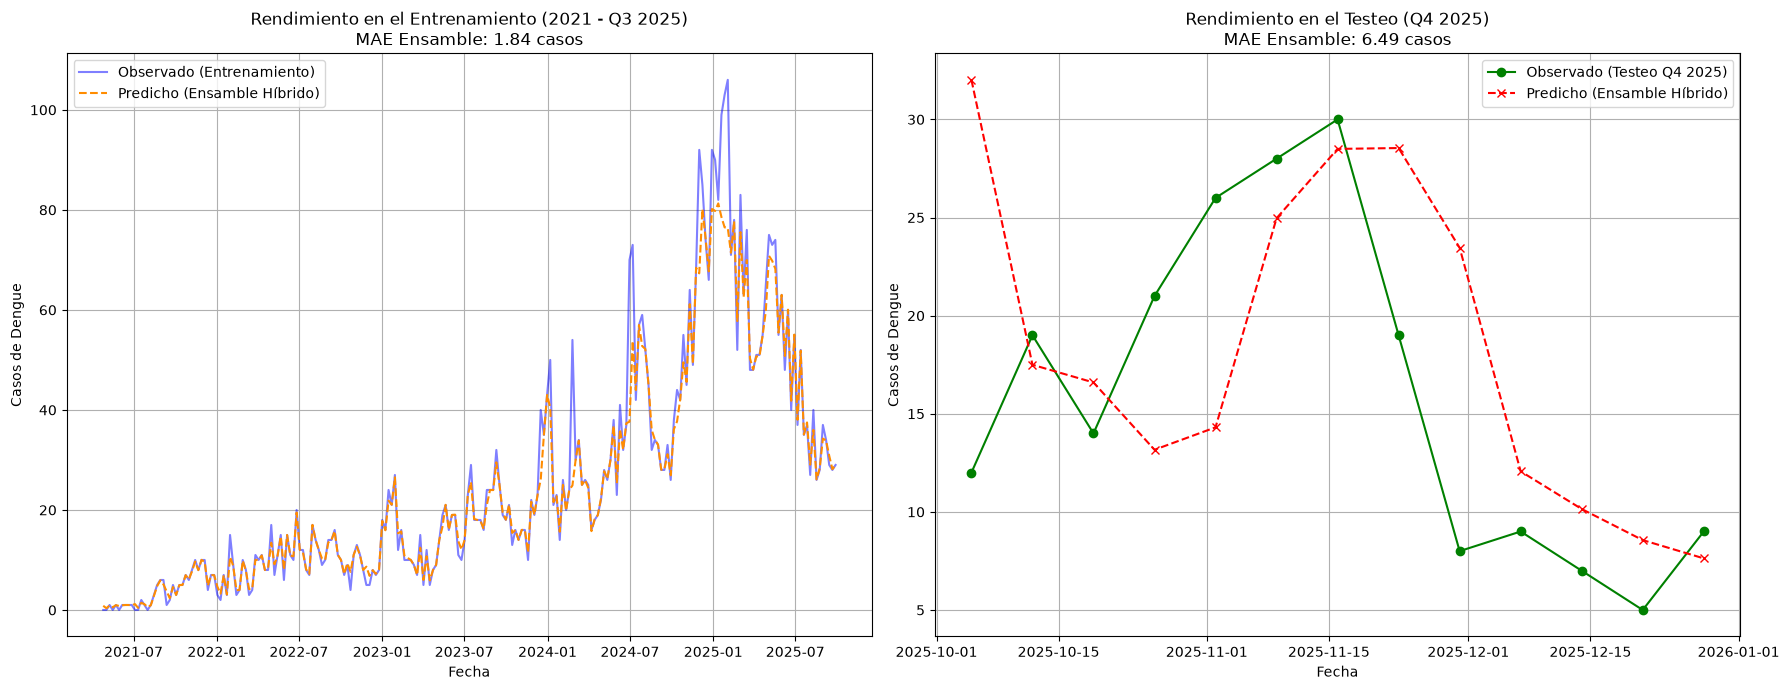

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from sklearn.metrics import mean_absolute_error
import warnings
warnings.filterwarnings('ignore')

# =============================================================================
# 1. CARGA DE DATOS Y PREPROCESAMIENTO
# =============================================================================
ruta_archivo = r"C:\Users\marco\Documentos\investigacion\machine_learning_idalina\4_algoritmo_LightGBM\2_entrenamiento_modelo_sat\2_datos\1_raw\2_meteo_epi_rezagos_spearman_20.xlsx"
df = pd.read_excel(ruta_archivo)

df['fecha'] = pd.to_datetime(df['fecha'])
df.set_index('fecha', inplace=True)
df = df.sort_index()

# Asegurar variables de escala objetivo
target_original = 'casos_dengue'
if 'casos_ln' not in df.columns:
    df['casos_ln'] = np.log1p(df[target_original])
target_log = 'casos_ln'

# =============================================================================
# SUGERENCIA 3: CODIFICACIÓN CÍCLICA DE LA SEMANA EPIDEMIOLÓGICA
# =============================================================================
if 'semana_epi' in df.columns:
    df['semana_sin'] = np.sin(2 * np.pi * df['semana_epi'] / 53)
    df['semana_cos'] = np.cos(2 * np.pi * df['semana_epi'] / 53)

# =============================================================================
# SUGERENCIA 4: INERCIA BIOLÓGICA (VARIABLES AUTORREGRESIVAS DE CORRTO PLAZO)
# =============================================================================
# Agregamos los retrasos de la propia variable en escala logarítmica para evitar saltos bruscos
df['target_lag_1'] = df[target_log].shift(1)
df['target_lag_2'] = df[target_log].shift(2)
df['target_roll_mean_4'] = df[target_log].shift(1).rolling(4).mean()

# Al crear lags y medias móviles se generan filas con NaN al inicio; las eliminamos
df.dropna(inplace=True)

# Definir la lista final de variables predictoras (las 20 originales + las nuevas agregadas)
excluir = [target_original, target_log, 'año', 'semana_epi']
features = [col for col in df.columns if col not in excluir]

X = df[features]
y = df[target_log]

# División cronológica para el entrenamiento y testeo final
X_train_full = X.loc['2021-01-01':'2025-09-30']
y_train_full = y.loc['2021-01-01':'2025-09-30']

X_test = X.loc['2025-10-01':'2025-12-31']
y_test = y.loc['2025-10-01':'2025-12-31']

y_train_original = df.loc['2021-01-01':'2025-09-30', target_original]
y_test_original = df.loc['2025-10-01':'2025-12-31', target_original]

# =============================================================================
# SUGERENCIA 2: CONFIGURACIÓN DE VENTANA DESPLAZABLE (SLIDING WINDOW) EN CV
# =============================================================================
# Modificamos el comportamiento de TimeSeriesSplit mediante una función personalizada 
# para simular una ventana desplazable (Sliding Window) de máximo ~104 semanas (2 años) de entrenamiento por Fold.
class SlidingTimeSeriesSplit:
    def __init__(self, n_splits=5, train_window=104):
        self.tscv = TimeSeriesSplit(n_splits=n_splits)
        self.train_window = train_window
        
    def split(self, X, y=None, groups=None):
        for train_index, test_index in self.tscv.split(X, y, groups):
            # Recortamos el inicio del entrenamiento para mantener una ventana fija hacia atrás
            if len(train_index) > self.train_window:
                train_index = train_index[-self.train_window:]
            yield train_index, test_index
            
    def get_n_splits(self, X, y=None, groups=None):
        return self.tscv.get_n_splits(X, y, groups)

cv_sliding = SlidingTimeSeriesSplit(n_splits=5, train_window=104)

# =============================================================================
# SUGERENCIA 1 Y 5: AFINAMIENTO CON REGULARIZACIÓN Y ENSAMBLE HÍBRIDO
# =============================================================================
# Malla para LightGBM incluyendo parámetros avanzados de regularización (Sugerencia 1)
grid_lgbm = {
    'n_estimators': [100, 150, 200],
    'max_depth': [4, 6, -1],
    'learning_rate': [0.05, 0.1],
    'num_leaves': [7, 15, 31],
    'min_child_samples': [10, 20],   # Evita sobreajuste en hojas con pocos datos
    'reg_alpha': [0.0, 0.1, 1.0],    # Regularización L1
    'reg_lambda': [0.0, 1.0, 10.0]   # Regularización L2
}

# Malla para XGBoost
grid_xgb = {
    'n_estimators': [100, 150, 200],
    'max_depth': [4, 5, 6],
    'learning_rate': [0.05, 0.1],
    'subsample': [0.7, 0.8]
}

print("1/2. Afinando LightGBM con parámetros de regularización y ventana móvil...")
gs_lgbm = GridSearchCV(
    estimator=LGBMRegressor(random_state=42, objective='regression_l1', verbose=-1),
    param_grid=grid_lgbm, cv=cv_sliding, scoring='neg_mean_absolute_error', n_jobs=-1
)
gs_lgbm.fit(X_train_full, y_train_full)
best_lgbm = gs_lgbm.best_estimator_

print("2/2. Afinando XGBoost con ventana móvil...")
gs_xgb = GridSearchCV(
    estimator=XGBRegressor(random_state=42, objective='reg:absoluteerror'),
    param_grid=grid_xgb, cv=cv_sliding, scoring='neg_mean_absolute_error', n_jobs=-1
)
gs_xgb.fit(X_train_full, y_train_full)
best_xgb = gs_xgb.best_estimator_

# =============================================================================
# PREDICCIONES Y ENSEMBLE (SUGERENCIA 5)
# =============================================================================
# Generar predicciones individuales en escala log
pred_train_lgbm_log = best_lgbm.predict(X_train_full)
pred_test_lgbm_log = best_lgbm.predict(X_test)

pred_train_xgb_log = best_xgb.predict(X_train_full)
pred_test_xgb_log = best_xgb.predict(X_test)

# Combinación del ensamble mediante promedio matemático (escala log)
ensemble_train_log = (pred_train_lgbm_log + pred_train_xgb_log) / 2
ensemble_test_log = (pred_test_lgbm_log + pred_test_xgb_log) / 2

# Transformación Inversa (np.expm1) a unidades reales de casos
y_train_pred_original = pd.Series(np.expm1(ensemble_train_log), index=y_train_full.index)
y_test_pred_original = pd.Series(np.expm1(ensemble_test_log), index=y_test.index)

# Cálculo de Métricas Finales del Ensamble Híbrido
mae_train_final = mean_absolute_error(y_train_original, y_train_pred_original)
mae_test_final = mean_absolute_error(y_test_original, y_test_pred_original)

print("\n" + "="*50)
print(f"Mejores parámetros LightGBM: {gs_lgbm.best_params_}")
print(f"Mejores parámetros XGBoost: {gs_xgb.best_params_}")
print("="*50)
print(f"MAE Entrenamiento Final del Ensamble (Casos): {mae_train_final:.4f}")
print(f"MAE Testeo Final Q4 2025 del Ensamble (Casos): {mae_test_final:.4f}")
print("="*50)

# =============================================================================
# 9. GRAFICACIÓN DE RESULTADOS OBSERVAOS VS PREDICHOS (UNO AL LADO DEL OTRO)
# =============================================================================
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Panel Izquierdo: Entrenamiento completo
axes[0].plot(y_train_original.index, y_train_original.values, label='Observado (Entrenamiento)', color='blue', alpha=0.5)
axes[0].plot(y_train_pred_original.index, y_train_pred_original.values, label='Predicho (Ensamble Híbrido)', color='darkorange', linestyle='--')
axes[0].set_title(f'Rendimiento en el Entrenamiento (2021 - Q3 2025)\nMAE Ensamble: {mae_train_final:.2f} casos')
axes[0].set_ylabel('Casos de Dengue')
axes[0].set_xlabel('Fecha')
axes[0].legend()
axes[0].grid(True)

# Panel Derecho: Testeo (Último trimestre de 2025)
axes[1].plot(y_test_original.index, y_test_original.values, label='Observado (Testeo Q4 2025)', color='green', marker='o')
axes[1].plot(y_test_pred_original.index, y_test_pred_original.values, label='Predicho (Ensamble Híbrido)', color='red', linestyle='--', marker='x')
axes[1].set_title(f'Rendimiento en el Testeo (Q4 2025)\nMAE Ensamble: {mae_test_final:.2f} casos')
axes[1].set_ylabel('Casos de Dengue')
axes[1].set_xlabel('Fecha')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()



# ¿Qué debes esperar al correr este script?

Como **todas las sugerencias quedaron incorporadas**, no te hace falta ninguna por experimentar a nivel de arquitectura y código.

Al ejecutar las mallas, notarás que toma un poco más de tiempo de procesamiento debido a que está entrenando y optimizando ambos algoritmos de forma paralela (`GridSearchCV` x2) usando una validación mucho más rigurosa. Este enfoque combinado es la estrategia estándar en competencias de machine learning de alto nivel para series de tiempo.